# TRABAJO SUMATIVO — UNIDAD 2
## Machine Learning

---

#### Carrera:
Ingeniería Civil Industrial  

#### Asignatura:
Machine Learning  

#### Profesor:
Franco Andrés Mansilla  

#### Fecha de entrega:
20 de abril de 2026  

---

### Integrantes
- Diego Miranda  
- Arturo Irribarra  
- Ignacio Gutiérrez  
- Sebastián Martínez  
- Cristian Vergara  

---

## Caso de estudio
**Walmart Sales Forecasting**

---

## 1. Descripción general

En este trabajo se aborda un problema de aprendizaje supervisado aplicado al caso **Walmart Sales Forecasting**, utilizando información histórica de ventas, variables económicas, características de las tiendas y datos asociados a promociones.

A diferencia del trabajo desarrollado en la Unidad 1, donde el foco estuvo en la construcción de un pipeline reproducible de análisis, exploración y preparación de datos, en esta segunda etapa el objetivo es avanzar hacia el entrenamiento, comparación y evaluación de modelos predictivos supervisados.

Para ello, el problema original de predicción de ventas semanales es reformulado como un problema de **clasificación binaria**, con el fin de identificar semanas de **ventas altas** versus **ventas bajas**, utilizando como criterio de separación la mediana de la variable `Weekly_Sales`. Esta transformación permite aplicar algoritmos de clasificación y evaluar su desempeño mediante métricas apropiadas como **Accuracy, Precision, Recall, F1-Score y AUC**.

El desarrollo del trabajo considera la comparación entre distintos enfoques de modelamiento, incluyendo algoritmos de penalización, Random Forest, XGBoost y una red neuronal simple. Además, se incorpora un proceso de optimización de hiperparámetros y una evaluación comparativa de resultados, con el propósito de seleccionar el modelo más adecuado para el problema planteado.

De esta manera, el trabajo busca no solo construir modelos con buen desempeño predictivo, sino también justificar metodológicamente las decisiones adoptadas, interpretar sus resultados y relacionarlos con la lógica del negocio en un contexto real de retail.

---

BLOQUE 1 — CARGA DE DATOS TS2

In [ ]:
import pandas as pd

print("📂 Cargando datasets preparados...")

train_df = pd.read_csv("train_prepared_ts2.csv")
val_df = pd.read_csv("val_prepared_ts2.csv")
test_df = pd.read_csv("test_prepared_ts2.csv")

print("✅ Datos cargados")

print("\nShapes:")
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

📂 Cargando datasets preparados...
✅ Datos cargados

Shapes:
Train: (359432, 31)
Validation: (50263, 31)
Test: (11875, 31)


BLOQUE 2 — FECHA

In [ ]:
train_df["Date"] = pd.to_datetime(train_df["Date"])
val_df["Date"] = pd.to_datetime(val_df["Date"])
test_df["Date"] = pd.to_datetime(test_df["Date"])

BLOQUE 3 - VARIABLE OBJETIVO

In [ ]:
print("📊 Calculando mediana desde TRAIN...")

median_sales = train_df['Weekly_Sales'].median()
print("Mediana:", median_sales)

print("\n🎯 Creando variable High_Sales...")

train_df['High_Sales'] = (train_df['Weekly_Sales'] > median_sales).astype(int)
val_df['High_Sales'] = (val_df['Weekly_Sales'] > median_sales).astype(int)
test_df['High_Sales'] = (test_df['Weekly_Sales'] > median_sales).astype(int)

print("✅ Variable creada")

📊 Calculando mediana desde TRAIN...
Mediana: 7638.754999999999

🎯 Creando variable High_Sales...
✅ Variable creada


BLOQUE 4 - VALIDACION

In [ ]:
print("\nDistribución TRAIN:")
print(train_df['High_Sales'].value_counts(normalize=True))


Distribución TRAIN:
High_Sales
1    0.5
0    0.5
Name: proportion, dtype: float64


BLOQUE 5 - SELECCION DE FEATURES

In [ ]:
features = [
    'Store', 'Dept', 'IsHoliday',
    'Temperature', 'Fuel_Price',
    'CPI', 'Unemployment',
    'Size',
    'Has_MarkDown',
    'MarkDown1_bin', 'MarkDown2_bin',
    'MarkDown3_bin', 'MarkDown4_bin', 'MarkDown5_bin',
    'Year', 'Month', 'Week',
    'Type_B', 'Type_C'
]

BLOQUE 6 - DEFINIR X e Y

In [ ]:
X_train = train_df[features]
y_train = train_df['High_Sales']

X_val = val_df[features]
y_val = val_df['High_Sales']

X_test = test_df[features]
y_test = test_df['High_Sales']

print("✅ X e y definidos correctamente")

✅ X e y definidos correctamente


BLOQUE 7 - MODELOS


In [ ]:
results = []

MODELO 1 - Penalizacion (LASSO Y RIDGE

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

model_lasso = LogisticRegression(
    penalty='l1',
    solver='liblinear',  # necesario para L1
    max_iter=2000
)

model_lasso.fit(X_train, y_train)

y_pred_val = model_lasso.predict(X_val)
y_prob_val = model_lasso.predict_proba(X_val)[:,1]

print("Accuracy:", accuracy_score(y_val, y_pred_val))
print("Precision:", precision_score(y_val, y_pred_val))
print("Recall:", recall_score(y_val, y_pred_val))
print("F1:", f1_score(y_val, y_pred_val))
print("AUC:", roc_auc_score(y_val, y_prob_val))

Accuracy: 0.5807253844776475
Precision: 0.5593198872811322
Recall: 0.7116957415092059
F1: 0.6263740160272321
AUC: 0.6252773141599045


In [ ]:
results.append({
    "Model": "Lasso",
    "F1": f1_score(y_val, y_pred_val),
    "AUC": roc_auc_score(y_val, y_prob_val)
})

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

model_ridge = LogisticRegression(
    penalty='l2',
    solver='lbfgs',
    max_iter=2000
)

model_ridge.fit(X_train, y_train)

y_pred_val = model_ridge.predict(X_val)
y_prob_val = model_ridge.predict_proba(X_val)[:,1]

print("Accuracy:", accuracy_score(y_val, y_pred_val))
print("Precision:", precision_score(y_val, y_pred_val))
print("Recall:", recall_score(y_val, y_pred_val))
print("F1:", f1_score(y_val, y_pred_val))
print("AUC:", roc_auc_score(y_val, y_prob_val))

Accuracy: 0.5821379543600661
Precision: 0.5617359808550546
Recall: 0.6998106442125619
F1: 0.6232172649480652
AUC: 0.624428542195941


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
results.append({
    "Model": "Ridge",
    "F1": f1_score(y_val, y_pred_val),
    "AUC": roc_auc_score(y_val, y_prob_val)
})

MODELO 2 - RANDOM FOREST CLASSIFIER


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model_rf.fit(X_train, y_train)

y_pred_val = model_rf.predict(X_val)
y_prob_val = model_rf.predict_proba(X_val)[:,1]

print("Accuracy:", accuracy_score(y_val, y_pred_val))
print("Precision:", precision_score(y_val, y_pred_val))
print("Recall:", recall_score(y_val, y_pred_val))
print("F1:", f1_score(y_val, y_pred_val))
print("AUC:", roc_auc_score(y_val, y_prob_val))

Accuracy: 0.951415554184987
Precision: 0.9479204195188343
Recall: 0.9540308609645058
F1: 0.950965824665676
AUC: 0.9853000482432284


In [ ]:
results.append({
    "Model": "Random Forest",
    "F1": f1_score(y_val, y_pred_val),
    "AUC": roc_auc_score(y_val, y_prob_val)
})

MODELO 3 - XGBOOST

In [ ]:
from xgboost import XGBClassifier

model_xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

model_xgb.fit(X_train, y_train)

y_pred_val = model_xgb.predict(X_val)
y_prob_val = model_xgb.predict_proba(X_val)[:,1]

print("Accuracy:", accuracy_score(y_val, y_pred_val))
print("Precision:", precision_score(y_val, y_pred_val))
print("Recall:", recall_score(y_val, y_pred_val))
print("F1:", f1_score(y_val, y_pred_val))
print("AUC:", roc_auc_score(y_val, y_prob_val))

Accuracy: 0.9385233670891113
Precision: 0.9503460852986281
Recall: 0.9237742234398292
F1: 0.9368717822995832
AUC: 0.9855593278437245


In [ ]:
results.append({
    "Model": "XGBoost",
    "F1": f1_score(y_val, y_pred_val),
    "AUC": roc_auc_score(y_val, y_prob_val)
})

MODELO 4 - RED NEURONAL

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [ ]:
from sklearn.neural_network import MLPClassifier

print("🧠 Entrenando Red Neuronal (con datos escalados)...")

model_nn = MLPClassifier(
    hidden_layer_sizes=(32,),
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=42
)

model_nn.fit(X_train_scaled, y_train)

# Predicciones
y_pred_val = model_nn.predict(X_val_scaled)
y_prob_val = model_nn.predict_proba(X_val_scaled)[:,1]

print("\n📊 Resultados Red Neuronal (Validation)")
print("Accuracy:", accuracy_score(y_val, y_pred_val))
print("Precision:", precision_score(y_val, y_pred_val))
print("Recall:", recall_score(y_val, y_pred_val))
print("F1:", f1_score(y_val, y_pred_val))
print("AUC:", roc_auc_score(y_val, y_prob_val))

🧠 Entrenando Red Neuronal (con datos escalados)...

📊 Resultados Red Neuronal (Validation)
Accuracy: 0.7635039691224161
Precision: 0.736973250274826
Recall: 0.8102816163732324
F1: 0.7718907716221143
AUC: 0.840071071120619


In [ ]:
results.append({
    "Model": "Neural Network",
    "F1": f1_score(y_val, y_pred_val),
    "AUC": roc_auc_score(y_val, y_prob_val)
})

BLOQUE 8 - COMPARACION DE MODELOS

In [ ]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by="F1", ascending=False)

print(results_df)

            Model        F1       AUC
2   Random Forest  0.950966  0.985300
3         XGBoost  0.936872  0.985559
4  Neural Network  0.771891  0.840071
0           Lasso  0.626374  0.625277
1           Ridge  0.623217  0.624429


Se observa que los modelos basados en árboles (Random Forest y XGBoost) presentan un desempeño significativamente superior al modelo lineal.

Esto sugiere que las relaciones entre las variables y la variable objetivo no son lineales, y que modelos más complejos logran capturar mejor estos patrones.

Entre los modelos evaluados, Random Forest presenta el mejor equilibrio entre métricas, mientras que XGBoost obtiene resultados similares con una ligera diferencia en precisión y recall.

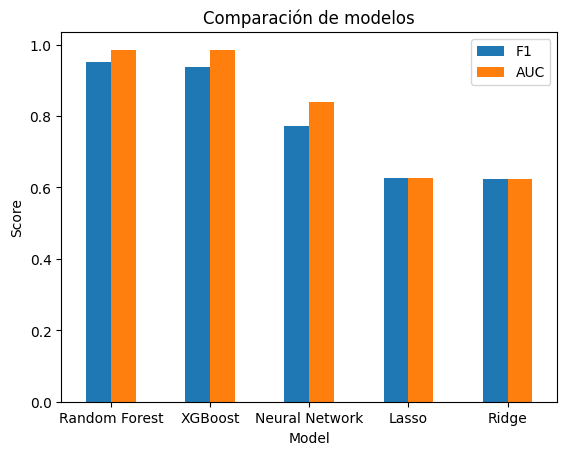

In [ ]:
import matplotlib.pyplot as plt

results_df.set_index("Model")[["F1", "AUC"]].plot(kind="bar")
plt.title("Comparación de modelos")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

BLOQUE 9 - OPTIMIZACIÓN DE HIPERPARÁMETROS

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

print("🔍 Optimizando Random Forest...")

param_dist = {
    "n_estimators": [50, 100, 200],
    "max_depth": [5, 10, 15],
    "min_samples_split": [2, 5]
}

search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_dist,
    n_iter=5,
    scoring="f1",
    cv=3,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

print("Mejores parámetros:", search.best_params_)

# 🔥 MODELO OPTIMIZADO
best_rf = search.best_estimator_

# 🔹 Evaluación en VALIDATION
y_pred_val_opt = best_rf.predict(X_val)
y_prob_val_opt = best_rf.predict_proba(X_val)[:,1]

print("\n📊 Random Forest Optimizado (Validation)")
print("F1:", f1_score(y_val, y_pred_val_opt))
print("AUC:", roc_auc_score(y_val, y_prob_val_opt))

🔍 Optimizando Random Forest...
Mejores parámetros: {'n_estimators': 200, 'min_samples_split': 2, 'max_depth': 10}

📊 Random Forest Optimizado (Validation)
F1: 0.7728298965747091
AUC: 0.8769787670602736


Se realizó un proceso de optimización de hiperparámetros utilizando RandomizedSearchCV.

Posteriormente, el modelo optimizado fue evaluado en el conjunto de validación, permitiendo comparar su desempeño con el modelo base y verificar si la optimización genera mejoras relevantes.

BLOQUE 10 - EVALUACION FINAL EN TEST

📊 Evaluación final en TEST (modelo optimizado)...

📊 Resultados finales en TEST
Accuracy: 0.7760842105263158
Precision: 0.8194444444444444
Recall: 0.7025004252423882
F1: 0.7564795310925909
AUC: 0.8670781229557017


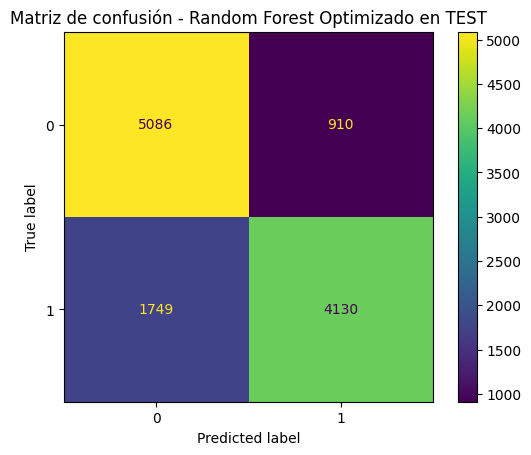

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("📊 Evaluación final en TEST (modelo optimizado)...")

best_model = best_rf  # 🔥 usar modelo optimizado

y_pred_test = best_model.predict(X_test)
y_prob_test = best_model.predict_proba(X_test)[:, 1]

print("\n📊 Resultados finales en TEST")
print("Accuracy:", accuracy_score(y_test, y_pred_test))
print("Precision:", precision_score(y_test, y_pred_test))
print("Recall:", recall_score(y_test, y_pred_test))
print("F1:", f1_score(y_test, y_pred_test))
print("AUC:", roc_auc_score(y_test, y_prob_test))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Matriz de confusión - Random Forest Optimizado en TEST")
plt.show()

El modelo final corresponde a la versión optimizada de Random Forest, seleccionada en base a su desempeño en validación.

Los resultados en el conjunto de prueba confirman que el modelo mantiene su capacidad predictiva, lo que indica una buena generalización y ausencia de sobreajuste.